# Creating a wildtype (WT), and Parkinson degeneration (PD) network

In the directory ```network_path``` we have three sub directories ```WT```, ```PD-ref``` and ```PD```. In order to generate the ```PD``` network, we degenerate the ```WT``` network by swapping the WT morphologies for the PD morphologies. In addition a subset of the synapses in the ```PD-ref``` network are added to compensate for differences in pruning.

We need to specify a ```connection_override``` file. The difference compared to the standard connection file is that it contains ```recovery``` information, i.e. the fraction of synapses from the ```PD-ref``` network that should be added to the ```PD``` network.

The ```rc``` object is a ```ipyparallel``` ```RemoteClient``` object for parallel execution.

If you want to remap external input that was removed to a new position, then use ```remap_removed_input = True```

In [1]:
import os

network_path = os.path.join("networks","PD-example-100")
#network_path = os.path.join("networks","PD-example-2_ref_0.9")

network_path_wt = os.path.join(network_path, "WT")
network_path_pd_ref = os.path.join(network_path, "PD-ref")
network_path_pd = os.path.join(network_path, "PD")

network_size = 100
input_config = "test-input.json"  # Only background input will be used in this example

snudda_data_base_path = os.path.join("..", "..", "..", "..", "BasalGangliaData", "Parkinson", "PD2026")
snudda_data_wt = os.path.join(snudda_data_base_path, "WT")
snudda_data_pd = os.path.join(snudda_data_base_path, "PD")

network_config_wt = os.path.join(snudda_data_wt, "connectivity", "striatum", "striatum-connectivity.json")
# network_config_pd = os.path.join(snudda_data_pd, "connectivity", "network-config-PD-synapse-recovery.json")
# network_config_pd = os.path.join(snudda_data_pd, "connectivity", "network-config-PD-basic.json")
network_config_pd = network_config_wt


input_wt = os.path.join(network_path_wt, "input-spikes.hdf5")
input_pd = os.path.join(network_path_pd, "input-spikes.hdf5")

# Do we want to remap removed input?
remap_removed_input = False
remapped_fraction = 0.0

# Do we want to remap removed input? -- if so we need to use network-config-PD-synapse.recovery.json also.
#remap_removed_input = True
#remapped_fraction = 0.9

rc = None

## First generate the WT reference network

In [2]:
from snudda import SnuddaInit

si = SnuddaInit(network_path=network_path_wt, random_seed=123456, snudda_data=snudda_data_wt,
                struct_def={"Striatum": network_size}, connection_override_file=network_config_wt)

Adding Striatum with 100 neurons (stay_inside=False)
Using cube for striatum
Neurons for striatum read from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum
Adding neurons: FS from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/fs
Reading neuron paths for FS from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/fs/fs.json
Adding neurons: dSPN from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn
Reading neuron paths for dSPN from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn/dspn.json
Adding neurons: iSPN from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/ispn
Reading neuron paths for iSPN from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/ispn/ispn.json
Adding neurons: ChIN from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/chin
Reading neuron paths for ChIN from /home/hjo

In [3]:
from snudda import Snudda
snd_wt = Snudda(network_path=network_path_wt)
snd_wt.create_network()

Placing neurons
Network path: networks/PD-example-100/WT
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Region Striatum uses random seed 2636268905
Generating 628 points for networks/PD-example-100/WT/mesh/Striatum-cube-mesh-0.00010749824478388102.obj
Filtering, keeping inside points: 124 / 274
neuron_name = 'FS_0', num = np.int64(0), neuron_path = '$SNUDDA_DATA/neurons/striatum/fs/str-fs-e160628_FS2-mMTC180800A-IDB-v20220614'
neuron_name = 'FS_1', num = np.int64(0), neuron_path = '$SNUDDA_DATA/neurons/striatum/fs/str-fs-e161024_FS16-mDR-rat-Mar-13-08-1-536-R-v20220614'
neuron_name = 'FS_2', num = np.int64(1), neuron_path = '$SNUDDA_DATA/neurons/striatum/fs/str-fs-e161205_FS1-mBE104E-v20220614'
neuron_name = 'FS_3', num = np.int64(0), neuron_path = '$SNUDDA_DATA/neurons/striatum/fs/str-fs-e161205_FS1-mMTC180800A-IDB-v20220614'
neuron_name = 'FS_4', num = np.int64(0), neuron_path = '$SNUDDA_DATA/neurons/stria

In [4]:
snd_wt.setup_input(input_config=input_config)

Setting up inputs, assuming input.json exists
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Writing input spikes to networks/PD-example-100/WT/input-spikes.hdf5
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
!!! Warning, combining definition of cortical with cortical input for neuron FS_2 (0) (meta modified by input_config)
!!! Warning, combining definition of cortical with cortical input for neuron dSPN_0 (1) (meta modified by input_config)
!!! Warning, combining definition of thalamic with thalamic input for neuron dSPN_0 (1) (meta modified by input_config)
!!! Warning, combining definition of cortical with cortical input for neuron dSPN_0 (2) (meta modified by input_config)
!!! Warning, combining definition of thalamic with thalamic input for neuron dSPN_0 (2) (meta modified by input_config)
!!! Warning, combining definition o

## Generate a PD reference network

This network will not have the same synapses as the WT, but it is used in order to add "recovery synapses" to compensate for part of the degeneration.

In [5]:
from snudda import SnuddaInit

si = SnuddaInit(network_path=network_path_pd_ref, random_seed=123456, snudda_data=snudda_data_pd,
                struct_def={"Striatum": network_size}, connection_override_file=network_config_pd)

Adding Striatum with 100 neurons (stay_inside=False)
Using cube for striatum
Neurons for striatum read from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum
Adding neurons: FS from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/fs
Reading neuron paths for FS from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/fs/fs.json
Adding neurons: dSPN from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn
Adding neurons: iSPN from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/ispn
Adding neurons: ChIN from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/chin
Reading neuron paths for ChIN from /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/chin/chin.json
Adding neurons: LTS from dir /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/lts
Reading neuron paths for LTS from /home/hjorth/HBP/BasalGangl

In [6]:
from snudda import Snudda
from snudda.utils.force_morphology_variations import ForceMorphologyVariations

#This copies the WT network to PD-ref, and swaps morphologies and models to match
fmv = ForceMorphologyVariations(network_path=network_path_pd_ref, original_network_path=network_path_wt)
fmv.swap()

pd_ref_config = os.path.join(network_path_pd_ref, "network-config.json")
print(f"{pd_ref_config}")
    
snd_pd_ref = Snudda(network_path=network_path_pd_ref)
snd_pd_ref.detect_synapses(config_file=pd_ref_config)
snd_pd_ref.prune_synapses()
# snd_pd_ref.create_network()

Template: networks/PD-example-100/WT/network-neuron-positions.hdf5
Updated place file: networks/PD-example-100/PD-ref/network-neuron-positions.hdf5
Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-pd-v20260604 instead of /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01
Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-pd-v20260604 instead of /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01
Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-pd-v20260604 instead of /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150

In [7]:
snd_pd_ref.setup_input(input_config=input_config)

Setting up inputs, assuming input.json exists
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD from networks/PD-example-100/PD-ref/network-config.json
Writing input spikes to networks/PD-example-100/PD-ref/input-spikes.hdf5
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD from networks/PD-example-100/PD-ref/network-config.json
!!! Warning, combining definition of cortical with cortical input for neuron FS_2 (0) (meta modified by input_config)
Writing spikes to networks/PD-example-100/PD-ref/input-spikes.hdf5
Calling cleanup on workers (log file already closed).


## Degenerating the WT network to get PD network

network_file_wt = os.path.join(network_path_wt, "network-synapses.hdf5")
network_file_pd_ref = os.path.join(network_path_pd_ref, "network-synapses.hdf5")
network_file_pd = os.path.join(network_path_pd, "network-synapses.hdf5")

from snudda.utils.swap_to_degenerated_morphologies_extended import SwapToDegeneratedMorphologiesExtended
swap = SwapToDegeneratedMorphologiesExtended(original_network_file=network_file_wt,
                                             updated_network_file=network_file_pd_ref,
                                             output_network_file=network_file_pd,
                                             original_snudda_data_dir=snudda_data_wt,
                                             updated_snudda_data_dir=snudda_data_pd,
                                             original_input_file=input_wt,
                                             output_input_file=input_pd)
swap.write_new_network_file()
swap.write_new_input_file(remap_removed_input=remap_removed_input, remapped_fraction=remapped_fraction)
swap.close()

In [8]:
network_file_wt = os.path.join(network_path_wt, "network-synapses.hdf5")
network_file_pd_ref = os.path.join(network_path_pd_ref, "network-synapses.hdf5")
network_file_pd = os.path.join(network_path_pd, "network-synapses.hdf5")

from snudda.utils.swap_to_degenerated_morphologies import SwapToDegeneratedMorphologies
swap = SwapToDegeneratedMorphologies(original_network_file=network_file_wt,
                                     new_network_file=network_file_pd,
                                     original_snudda_data_dir=snudda_data_wt,
                                     new_snudda_data_dir=snudda_data_pd,
                                     original_input_file=input_wt,
                                     new_input_file=input_pd)
swap.write_new_network_file()
swap.write_new_input_file(remap_removed_input=remap_removed_input, remapped_fraction=remapped_fraction)
swap.close()

Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-pd-v20260604 instead of /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01
Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-pd-v20260604 instead of /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01
Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01-pd-v20260604 instead of /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150602_c1_D1-mWT-0728MSN01
Did not find exact directory match, using /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-ds

## Plotting of a degenerated neuron

In [9]:
# This is so we get the most central dSPN in the network
from snudda import SnuddaLoad
sl = SnuddaLoad(network_path_wt)
neuron_id = list(sl.get_centre_neurons_iterator(neuron_type="dSPN", n_neurons=1))[0][0]

In [10]:
# neuron_id = 55
neuron_id

np.int64(40)

Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn/str-dspn-e150917_c9_d1-mWT-1215MSN03/morphology/WT-1215MSN03-var3.swc
Plotting 979 external synapses
Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn/str-dspn-e150917_c9_d1-mWT-1215MSN03/morphology/WT-1215MSN03-var3.swc
Plotting 979 external synapses


/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:120: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=coords[:, 0], ys=coords[:, 1], zs=coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:127: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=syn_coords[:, 0], ys=syn_coords[:, 1], zs=syn_coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.p

Figure written: networks/PD-example-100/WT/figures/input-to-40-dSPN_3-and-internal-synapses.png


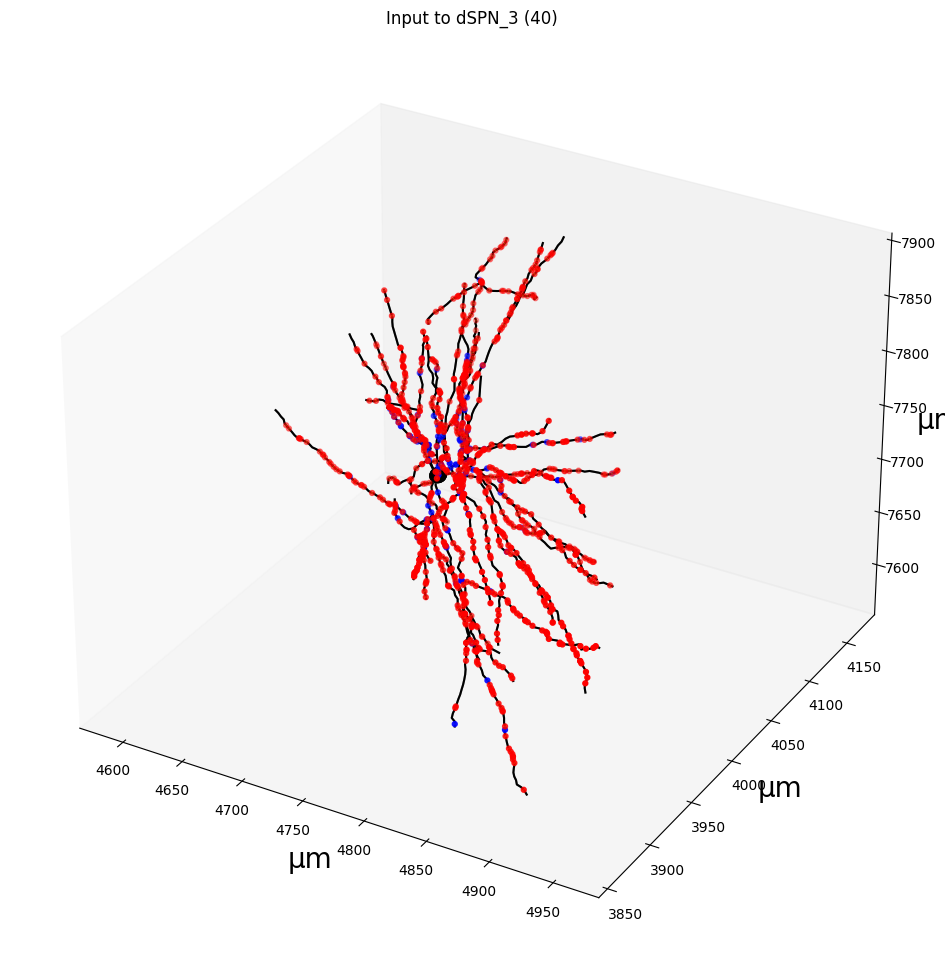

In [11]:
%matplotlib inline
from snudda.plotting.plot_degeneration import PlotDegeneration

# Note here original and degenerate path were the same, so we are plotting the full neuron and its synapses.
pd = PlotDegeneration(original_network_path=network_path_wt,
                      degenerated_network_path=network_path_wt)

pd.plot_neuron(neuron_id=neuron_id, figure_size=(12,12), 
               show_internal_synapses=True, hide_axis=False)
#internal synapses are blue
#external synapses are red

neuron_id = np.int64(35)
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Reading SNUDDA_DATA=../../../../BasalGangliaData/Parkinson/PD2026/PD from networks/PD-example-100/PD/network-synapses.hdf5
Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn/str-dspn-e150917_c6_D1-m21-6-DE/morphology/21-6-DE-var8.swc
Plotting 435 external synapses


/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:120: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=coords[:, 0], ys=coords[:, 1], zs=coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:127: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=syn_coords[:, 0], ys=syn_coords[:, 1], zs=syn_coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.p

Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150917_c6_D1-m21-6-DE-pd-v20260604/morphology/21-6-DE-var8-6ohda9.swc
Plotting 236 external synapses
Figure written: networks/PD-example-100/PD/figures/input-to-35-dSPN_2-and-internal-synapses.png


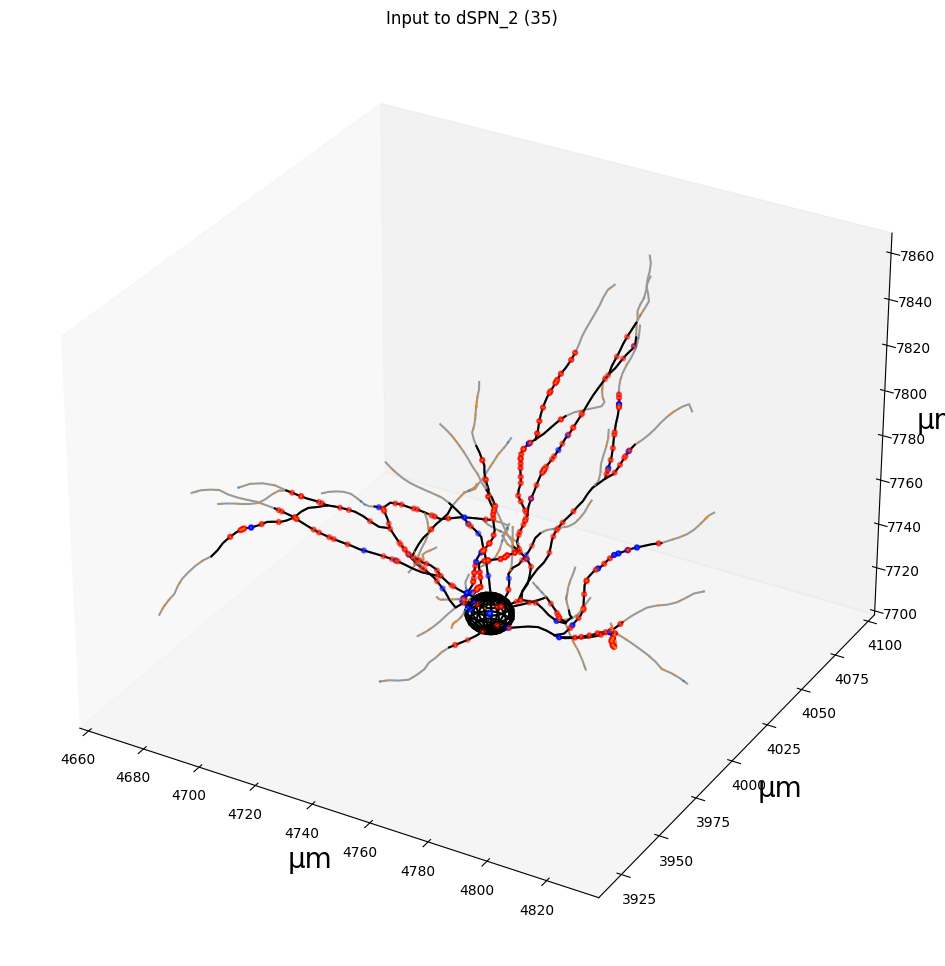

In [12]:
%matplotlib inline
from snudda.plotting.plot_degeneration import PlotDegeneration

# Temp check other neuron:
neuron_id = list(sl.get_centre_neurons_iterator(neuron_type="dSPN", n_neurons=10, return_distance=False))[1]
print(f"{neuron_id = }")

pd = PlotDegeneration(original_network_path=network_path_wt,
                      degenerated_network_path=network_path_pd)

pd.plot_neuron(neuron_id=neuron_id, figure_size=(12,12), 
               show_internal_synapses=True, hide_axis=False)

neuron_id = np.int64(35)
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Reading SNUDDA_DATA=../../../../BasalGangliaData/Parkinson/PD2026/PD from networks/PD-example-100/PD/network-synapses.hdf5
Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn/str-dspn-e150917_c6_D1-m21-6-DE/morphology/21-6-DE-var8.swc
Plotting 435 external synapses


/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:120: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=coords[:, 0], ys=coords[:, 1], zs=coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x_labels)
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:161: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_labels)
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:162: UserWarning:

Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150917_c6_D1-m21-6-DE-pd-v20260604/morphology/21-6-DE-var8-6ohda9.swc
Plotting 236 external synapses
Figure written: networks/PD-example-100/PD/figures/input-to-35-dSPN_2.png


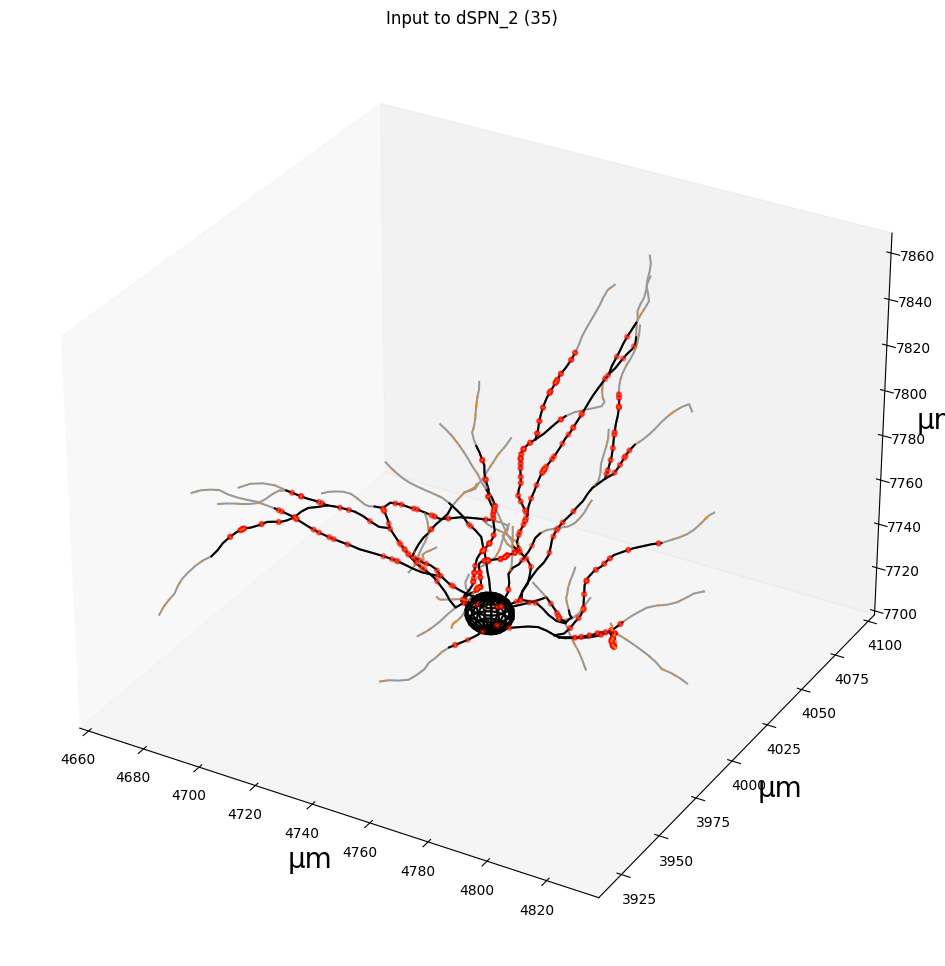

In [13]:
%matplotlib inline
from snudda.plotting.plot_degeneration import PlotDegeneration

# Temp check other neuron:
neuron_id = list(sl.get_centre_neurons_iterator(neuron_type="dSPN", n_neurons=10, return_distance=False))[1]
print(f"{neuron_id = }")

pd = PlotDegeneration(original_network_path=network_path_wt,
                      degenerated_network_path=network_path_pd)

pd.plot_neuron(neuron_id=neuron_id, figure_size=(12,12), 
               show_internal_synapses=False, hide_axis=False)

Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT from networks/PD-example-100/WT/network-config.json
Reading SNUDDA_DATA=/home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD from networks/PD-example-100/PD-ref/network-config.json
Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/WT/neurons/striatum/dspn/str-dspn-e150917_c6_D1-m21-6-DE/morphology/21-6-DE-var8.swc
Plotting 435 external synapses


/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:120: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=coords[:, 0], ys=coords[:, 1], zs=coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.py:127: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(xs=syn_coords[:, 0], ys=syn_coords[:, 1], zs=syn_coords[:, 2],
/home/hjorth/HBP/Snudda/snudda/plotting/plot_input_locations.p

Loading morphology: /home/hjorth/HBP/BasalGangliaData/Parkinson/PD2026/PD/neurons/striatum/dspn/str-dspn-e150917_c6_D1-m21-6-DE-pd-v20260604/morphology/21-6-DE-var8-6ohda9.swc
Plotting 200 external synapses
Figure written: networks/PD-example-100/PD-ref/figures/input-to-35-dSPN_2-and-internal-synapses.png


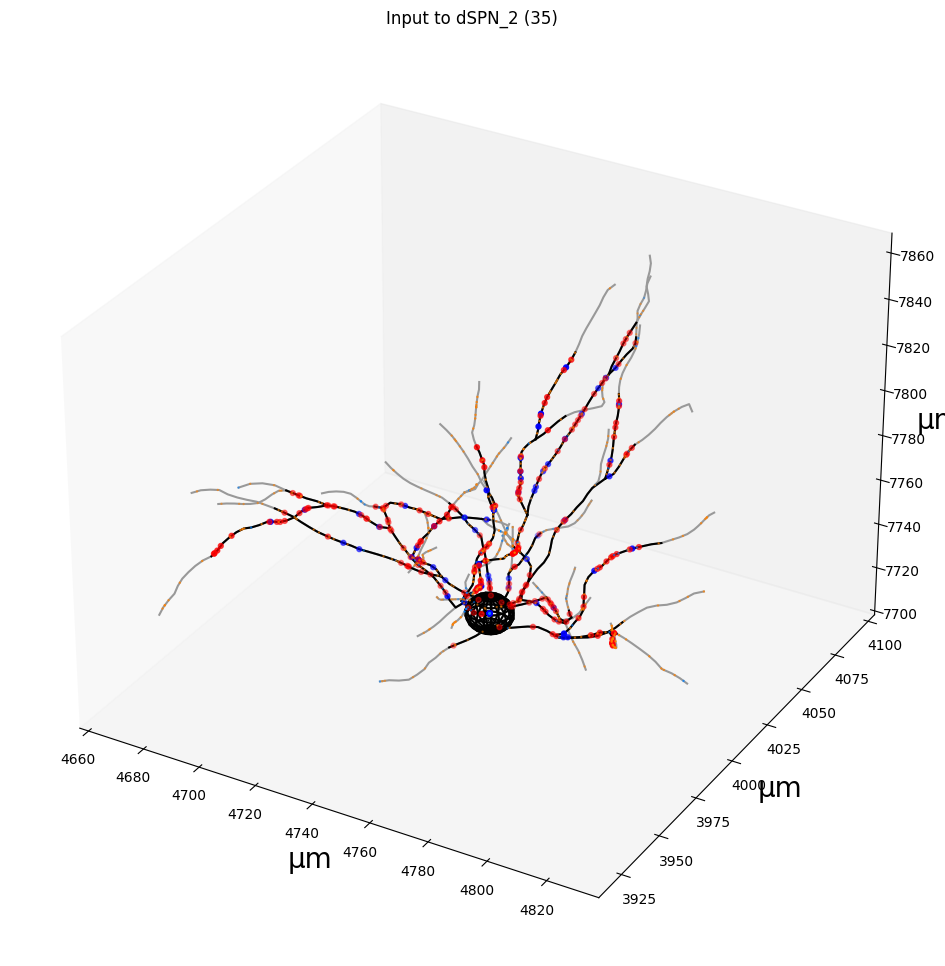

In [14]:
%matplotlib inline
from snudda.plotting.plot_degeneration import PlotDegeneration

pd = PlotDegeneration(original_network_path=network_path_wt,
                      degenerated_network_path=network_path_pd_ref)
#neuron_id = 55
pd.plot_neuron(neuron_id=neuron_id, figure_size=(12,12), 
               show_internal_synapses=True, hide_axis=False)

In [15]:
from snudda.analyse.analyse_input import AnalyseInput

wt_input_info = AnalyseInput(input_file=input_wt, network_path=network_path_wt)
pd_input_info = AnalyseInput(input_file=input_pd, network_path=network_path_pd)

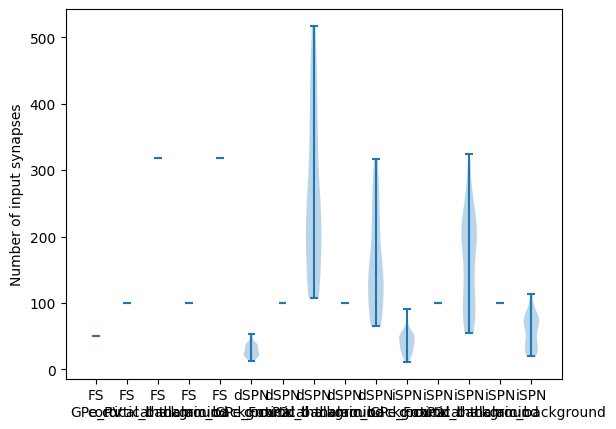

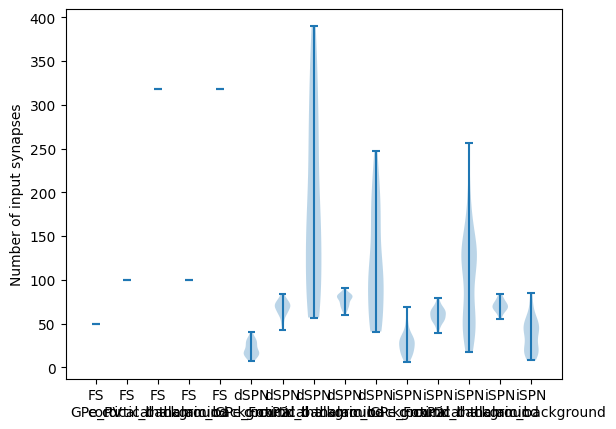

In [16]:
wt_input_info.plot_input_count("WT-input_example.png")
pd_input_info.plot_input_count("PD-input_example.png")

In [17]:
cmd_str1 = f"snudda_load {network_path_wt}/network-synapses.hdf5 --countSyn"
cmd_str2 = f"snudda_load {network_path_pd}/network-synapses.hdf5 --countSyn"
cmd_str3 = f"snudda_load {network_path_pd_ref}/network-synapses.hdf5 --countSyn"

print("WT")
os.system(cmd_str1)
print("\nPD")
os.system(cmd_str2)
print("\nPD degenerated")
os.system(cmd_str3)

WT
Loading networks/PD-example-100/WT/network-synapses.hdf5
Loading config data from HDF5
Loading 100 neurons with 6838 synapses and 0 gap junctions
Load done. 0.0
ChIN -> FS: 3 synapses
ChIN -> LTS: 6 synapses
ChIN -> dSPN: 40 synapses
ChIN -> iSPN: 25 synapses
FS -> dSPN: 148 synapses
FS -> iSPN: 42 synapses
LTS -> ChIN: 10 synapses
LTS -> dSPN: 39 synapses
LTS -> iSPN: 18 synapses
TH -> dSPN: 8 synapses
TH -> iSPN: 11 synapses
dSPN -> ChIN: 22 synapses
dSPN -> TH: 53 synapses
dSPN -> dSPN: 1570 synapses
dSPN -> iSPN: 567 synapses
iSPN -> ChIN: 24 synapses
iSPN -> TH: 51 synapses
iSPN -> dSPN: 1923 synapses
iSPN -> iSPN: 2278 synapses

PD
Loading networks/PD-example-100/PD/network-synapses.hdf5
Loading config data from HDF5
Loading 100 neurons with 5448 synapses and 0 gap junctions
Load done. 0.0
ChIN -> FS: 3 synapses
ChIN -> LTS: 6 synapses
ChIN -> dSPN: 30 synapses
ChIN -> iSPN: 18 synapses
FS -> dSPN: 137 synapses
FS -> iSPN: 40 synapses
LTS -> ChIN: 10 synapses
LTS -> dSPN: 33 s

0

In [18]:
cmd_str1 = f"snudda_load {network_path_wt}/network-synapses.hdf5 --listPre {neuron_id}"
cmd_str2 = f"snudda_load {network_path_pd}/network-synapses.hdf5 --listPre {neuron_id}"
cmd_str3 = f"snudda_load {network_path_pd_ref}/network-synapses.hdf5 --listPre {neuron_id}"

print("WT")
os.system(cmd_str1)
print("\nPD")
os.system(cmd_str2)
print("\nPD degenerated")
os.system(cmd_str3)

WT
Loading networks/PD-example-100/WT/network-synapses.hdf5
Loading config data from HDF5
Loading 100 neurons with 6838 synapses and 0 gap junctions
Load done. 0.0
List neurons pre-synaptic to neuron_id = 35 (dSPN_2)
The neuron receives 97 synapses
4 : dSPN_0 (5 synapses)
5 : dSPN_0 (4 synapses)
16 : dSPN_1 (5 synapses)
32 : dSPN_2 (4 synapses)
37 : dSPN_3 (5 synapses)
41 : dSPN_3 (5 synapses)
43 : dSPN_3 (5 synapses)
48 : dSPN_3 (3 synapses)
51 : iSPN_0 (4 synapses)
54 : iSPN_0 (3 synapses)
58 : iSPN_0 (5 synapses)
59 : iSPN_0 (5 synapses)
60 : iSPN_0 (6 synapses)
68 : iSPN_1 (3 synapses)
81 : iSPN_2 (6 synapses)
84 : iSPN_2 (5 synapses)
87 : iSPN_3 (6 synapses)
88 : iSPN_3 (5 synapses)
95 : iSPN_3 (5 synapses)
96 : iSPN_3 (4 synapses)
97 : ChIN_0 (4 synapses)

PD
Loading networks/PD-example-100/PD/network-synapses.hdf5
Loading config data from HDF5
Loading 100 neurons with 5448 synapses and 0 gap junctions
Load done. 0.0
List neurons pre-synaptic to neuron_id = 35 (dSPN_2)
The neuron

0

Added: 0, removed: 35, kept: 54


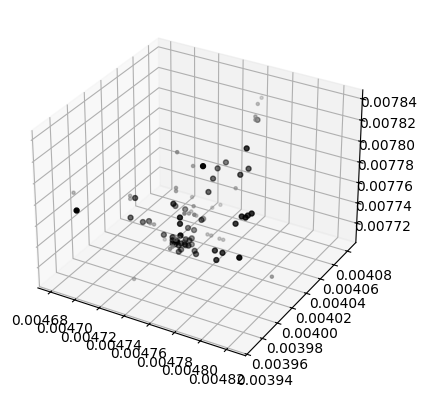

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

In [19]:
from snudda.plotting.plot_degeneration_and_growth import PlotDegenerationAndGrowth
pdg = PlotDegenerationAndGrowth(original_network_path=network_path_wt, 
                                degenerated_network_path=network_path_pd, 
                                neuron_id=neuron_id)
pdg.plot_synapses()

Added: 61, removed: 78, kept: 11


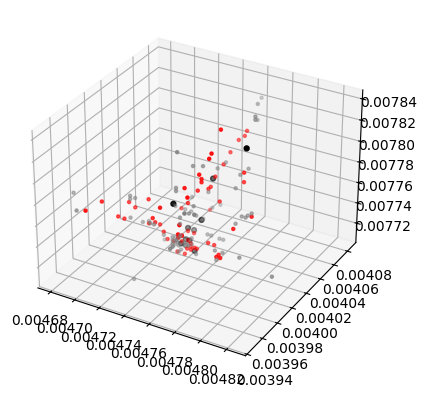

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

In [20]:
from snudda.plotting.plot_degeneration_and_growth import PlotDegenerationAndGrowth
pdg = PlotDegenerationAndGrowth(original_network_path=network_path_wt, 
                                degenerated_network_path=network_path_pd_ref, 
                                neuron_id=neuron_id)
pdg.plot_synapses()

In [21]:
from snudda.analyse.analyse import SnuddaAnalyse


network_file_wt = os.path.join(network_path_wt, "network-synapses.hdf5")
network_file_pd = os.path.join(network_path_pd, "network-synapses.hdf5")
network_file_pd_ref = os.path.join(network_path_pd_ref, "network-synapses.hdf5")

dist3D = False
y_max_H = None

sa_wt = SnuddaAnalyse(network_file_wt)
sa_pd = SnuddaAnalyse(network_file_pd)
sa_pd_ref = SnuddaAnalyse(network_file_pd_ref)    

Assuming volume type: cube [cube or full]
Only using 20000 neurons of the connection data
Number of neurons: 100
Synapse row 0 - 0.0 % time: 0.002780958020593971 seconds
Created connection matrix 0.014957417006371543 seconds
Created gap junction connection matrix 0.000149500003317371 seconds
Creating population dictionary
Done.
!!! Setting sideLen to None
Calculating synapse distance histogram
Creating dist histogram
n_synapses = 6838, at 0
Created distance histogram (optimised) in 0.010758792021078989 seconds
Saving cache to networks/PD-example-100/WT/network-synapses.hdf5-cache
Assuming volume type: cube [cube or full]
Only using 20000 neurons of the connection data
Number of neurons: 100
Synapse row 0 - 0.0 % time: 0.005263916013063863 seconds
Created connection matrix 0.008360291016288102 seconds
Created gap junction connection matrix 9.491702076047659e-05 seconds
Creating population dictionary
Done.
!!! Setting sideLen to None
Calculating synapse distance histogram
Creating dist h

Plotting connection probability dSPN to iSPN (synapses)
Centering in None : Keeping 48/48
Counting connections
Requested: 10000000.0 calculated [2304.]
Num pairs outside plot range 0
P(d<5e-05) = 0.06711409395973154
P(d<0.0001) = 0.05824811027123166
Plotting connection probability dSPN to iSPN (synapses)
Centering in None : Keeping 48/48
Counting connections
Requested: 10000000.0 calculated [2304.]
Num pairs outside plot range 0


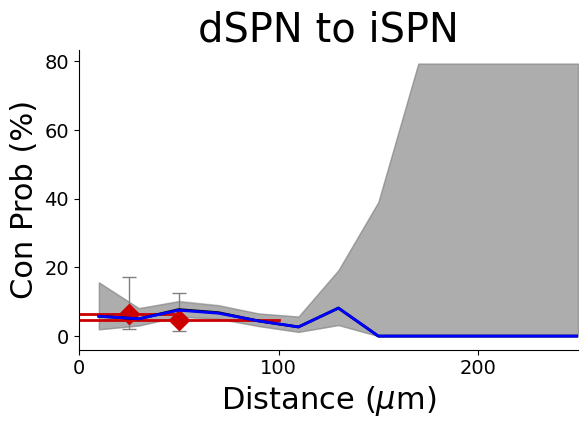

Wrote networks/PD-example-100/PD/figures/Network-distance-dependent-connection-probability-dSPN-to-iSPN-synapses-3D-dist.png


({},
 'networks/PD-example-100/PD/figures/Network-distance-dependent-connection-probability-dSPN-to-iSPN-synapses-3D-dist.png')

In [22]:
ax = sa_wt.plot_connection_probability("dSPN", "iSPN", dist_3d=True, exp_max_dist=[50e-6, 100e-6], exp_data_detailed=[(3, 47), (3, 66)], return_ax=True, show_plot=False, save_figure=False)
sa_pd.plot_connection_probability("dSPN", "iSPN", dist_3d=True, ax=ax, colour="blue")

Plotting number of connections
Only analysing centre post synaptic neurons, sideLen = 0.00025
Centering in None : Keeping 48/48
Calculating max synapses
Calculating mean synapses
Plotting 135 connections


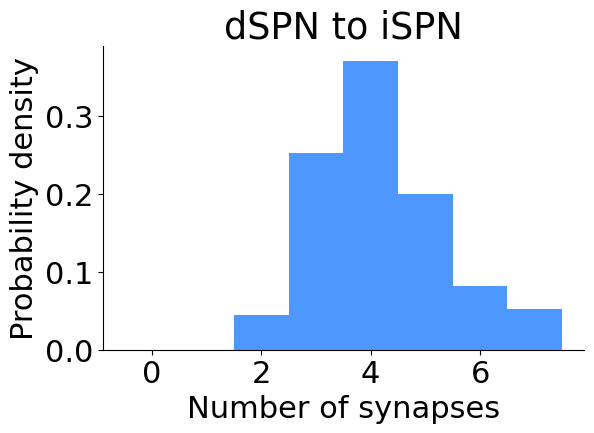

Wrote networks/PD-example-100/WT/figures/Network-number-of-synapses-from-dSPN-to-iSPN-per-cell.png
Plotting number of connections
Only analysing centre post synaptic neurons, sideLen = 0.00025
Centering in None : Keeping 48/48
Calculating max synapses
Calculating mean synapses
Plotting 133 connections


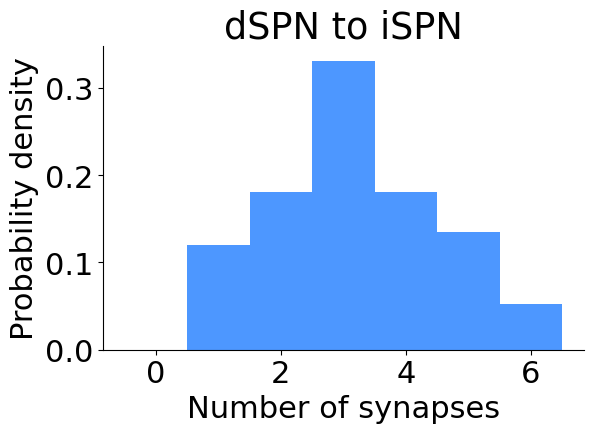

Wrote networks/PD-example-100/PD/figures/Network-number-of-synapses-from-dSPN-to-iSPN-per-cell.png


In [23]:
sa_wt.plot_num_synapses_per_pair("dSPN", "iSPN")
sa_pd.plot_num_synapses_per_pair("dSPN", "iSPN")

Plotting connection probability dSPN to dSPN (synapses)
Centering in None : Keeping 48/48
Counting connections
Requested: 10000000.0 calculated [2256.]
Num pairs outside plot range 0
P(d<5e-05) = 0.21021377672209027
P(d<0.0001) = 0.1627164995442115
Plotting connection probability dSPN to dSPN (synapses)
Centering in None : Keeping 48/48
Counting connections
Requested: 10000000.0 calculated [2256.]
Num pairs outside plot range 0
P(d<5e-05) = 0.20902612826603326


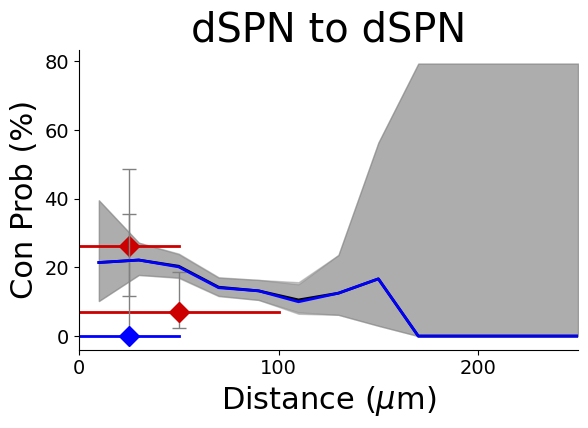

Wrote networks/PD-example-100/PD/figures/Network-distance-dependent-connection-probability-dSPN-to-dSPN-synapses-3D-dist.png
Plotting number of connections
Only analysing centre post synaptic neurons, sideLen = 0.00025
Centering in None : Keeping 48/48
Calculating max synapses
Calculating mean synapses
Plotting 365 connections


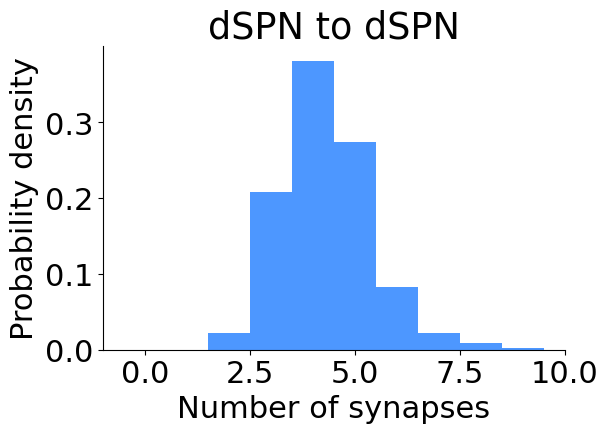

Wrote networks/PD-example-100/WT/figures/Network-number-of-synapses-from-dSPN-to-dSPN-per-cell.png
Plotting number of connections
Only analysing centre post synaptic neurons, sideLen = 0.00025
Centering in None : Keeping 48/48
Calculating max synapses
Calculating mean synapses
Plotting 362 connections


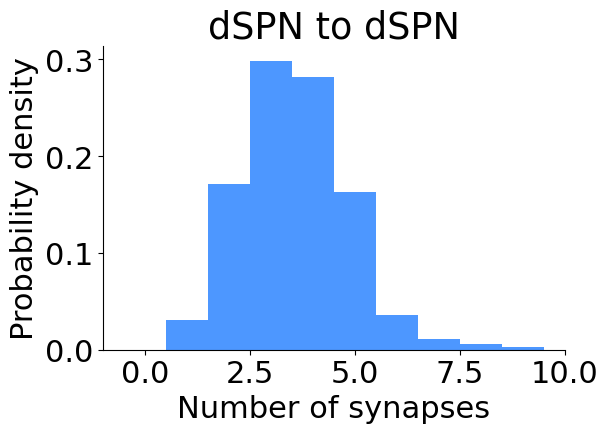

Wrote networks/PD-example-100/PD/figures/Network-number-of-synapses-from-dSPN-to-dSPN-per-cell.png


In [24]:
ax = sa_wt.plot_connection_probability("dSPN", "dSPN", dist_3d=True, exp_max_dist=[50e-6, 100e-6], exp_data_detailed=[(5, 19), (3, 43)], return_ax=True, show_plot=False, save_figure=False)
sa_pd.plot_connection_probability("dSPN", "dSPN", dist_3d=True, ax=ax, colour="blue", exp_colour="blue", exp_data_detailed=[(0, 7)], exp_max_dist=[50e-6])

sa_wt.plot_num_synapses_per_pair("dSPN", "dSPN")
sa_pd.plot_num_synapses_per_pair("dSPN", "dSPN")

Plotting connection probability iSPN to iSPN (synapses)
Centering in None : Keeping 48/48
Counting connections
Requested: 10000000.0 calculated [2256.]
Num pairs outside plot range 0
P(d<5e-05) = 0.30170316301703165
P(d<0.0001) = 0.240236148955495
Plotting connection probability iSPN to iSPN (synapses)
Centering in None : Keeping 48/48
Counting connections
Requested: 10000000.0 calculated [2256.]
Num pairs outside plot range 0
P(d<5e-05) = 0.29683698296836986


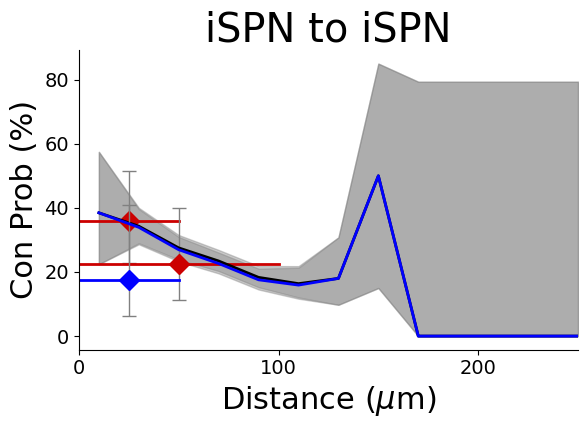

Wrote networks/PD-example-100/PD/figures/Network-distance-dependent-connection-probability-iSPN-to-iSPN-synapses-3D-dist.png
Plotting number of connections
Only analysing centre post synaptic neurons, sideLen = 0.00025
Centering in None : Keeping 48/48
Calculating max synapses
Calculating mean synapses
Plotting 540 connections


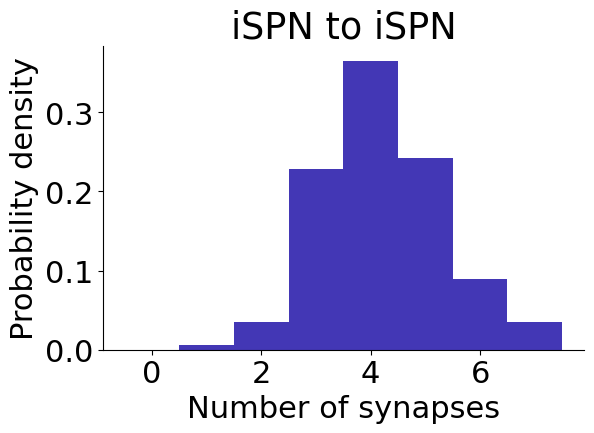

Wrote networks/PD-example-100/WT/figures/Network-number-of-synapses-from-iSPN-to-iSPN-per-cell.png


In [ ]:
ax = sa_wt.plot_connection_probability("iSPN", "iSPN", dist_3d=True, exp_max_dist=[50e-6, 100e-6], exp_data_detailed=[(14, 39), (7, 31)], return_ax=True, show_plot=False, save_figure=False)
# PD connectivity from Taverna et al 2008
sa_pd.plot_connection_probability("iSPN", "iSPN", dist_3d=True, ax=ax, colour="blue", exp_colour="blue", exp_data_detailed=[(3,17)], exp_max_dist=[50e-6])

sa_wt.plot_num_synapses_per_pair("iSPN", "iSPN")
sa_pd.plot_num_synapses_per_pair("iSPN", "iSPN")

In [ ]:
ax = sa_wt.plot_connection_probability("iSPN", "dSPN", dist_3d=True, exp_max_dist=[50e-6, 100e-6], exp_data_detailed=[(13, 47), (10, 80)], return_ax=True, show_plot=False, save_figure=False)
sa_pd.plot_connection_probability("iSPN", "dSPN", dist_3d=True, ax=ax, colour="blue", exp_colour="blue", exp_max_dist=[50e-6], exp_data_detailed=[(3, 12)])

sa_wt.plot_num_synapses_per_pair("iSPN", "dSPN")
sa_pd.plot_num_synapses_per_pair("iSPN", "dSPN")

In [ ]:
ax = sa_wt.plot_connection_probability("FS", "FS", dist_3d=True, exp_max_dist=[250e-6], exp_data_detailed=[(7, 12)], return_ax=True, show_plot=False, save_figure=False)
sa_pd.plot_connection_probability("FS", "FS", dist_3d=True, ax=ax, colour="blue")

sa_wt.plot_num_synapses_per_pair("FS", "FS")
sa_pd.plot_num_synapses_per_pair("FS", "FS")

In [ ]:
ax = sa_wt.plot_connection_probability("FS", "iSPN", dist_3d=True, exp_max_dist=[100e-6, 150e-6, 250e-6], exp_data_detailed=[(6, 9), (21, 54), (27,77)], return_ax=True, show_plot=False, save_figure=False)
sa_pd.plot_connection_probability("FS", "iSPN", dist_3d=True, ax=ax, colour="blue")

sa_wt.plot_num_synapses_per_pair("FS", "iSPN")
sa_pd.plot_num_synapses_per_pair("FS", "iSPN")

In [ ]:
ax = sa_wt.plot_connection_probability("FS", "dSPN", dist_3d=True, exp_max_dist=[100e-6, 150e-6, 250e-6], exp_data_detailed=[(8, 9), (29, 48), (48,90)], return_ax=True, show_plot=False, save_figure=False)
sa_pd.plot_connection_probability("FS", "dSPN", dist_3d=True, ax=ax, colour="blue")

sa_wt.plot_num_synapses_per_pair("FS", "dSPN")
sa_pd.plot_num_synapses_per_pair("FS", "dSPN")